# MY SECOND PROYEKT
---

### Dataset ustunlar va ularning o'zbekcha tavsifi

| # | Ustun nomi | O'zbekcha tavsifi |
|---|-----------|-------------------|
| 1 | **Customer ID** | Har bir mijozning noyob identifikator raqami |
| 2 | **Gender** | Mijoz jinsi — `Male` (Erkak) yoki `Female` (Ayol) |
| 3 | **Age** | Mijozning yoshi (26 dan 43 gacha) |
| 4 | **City** | Mijoz yashayotgan shahar nomi |
| 5 | **Membership Type** | A'zolik darajasi — `Bronze`, `Silver`, `Gold` |
| 6 | **Total Spend** | Mijoz jami sarflagan pul miqdori (dollar) **Regression target** |
| 7 | **Items Purchased** | Mijoz sotib olgan mahsulotlar soni |
| 8 | **Average Rating** | Mijozning o'rtacha baho ko'rsatkichi (1.0 dan 5.0 gacha) |
| 9 | **Discount Applied** | Chegirma qo'llanganmi? `True` yoki `False` |
| 10 | **Days Since Last Purchase** | Oxirgi xariddan bugungi kunga qadar o'tgan kunlar soni |
| 11 | **Satisfaction Level** | Mijoz qoniqish darajasi — `Unsatisfied`, `Neutral`, `Satisfied` **Classification target** |

---
## Data Collection

In [471]:
import pandas as pd
df=pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

### Papkalarni saqlab olish uchun file yaratish (OS)

In [472]:
import os
for folder in [
    "Data/Raw",
    "Data/Preprocessed",
    "Data/Engineered",
    "Data/Predictions",
    "Data_analysis",
    "Models",
    "Joblib_files"
]:
    os.makedirs(folder, exist_ok=True)

print("Papkalar muvaffaqiyatli yuklandi")

Papkalar muvaffaqiyatli yuklandi


In [473]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [474]:
# Asl datasetni Raw papkasiga saqlash
df.to_csv("Data/Raw/ecommerce_raw.csv", index=False)
print("Asl dataset Data/Raw/ papkasiga saqlandi.")

Asl dataset Data/Raw/ papkasiga saqlandi.


---
## Ma'lumotlarni tahlil qilish

In [475]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [476]:
df.describe().round(2)

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.00,350.00,350.00,350.00,350.00,350.00
mean,275.50,33.60,845.38,12.60,4.02,26.59
std,101.18,4.87,362.06,4.16,0.58,13.44
min,101.00,26.00,410.80,7.00,3.00,9.00
25%,188.25,30.00,502.00,9.00,3.50,15.00
50%,275.50,32.50,775.20,12.00,4.10,23.00
75%,362.75,37.00,1160.60,15.00,4.50,38.00
max,450.00,43.00,1520.10,21.00,4.90,63.00


In [477]:
null_count = df.isnull().sum()
print(null_count)

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


GridSpec(6, 6)

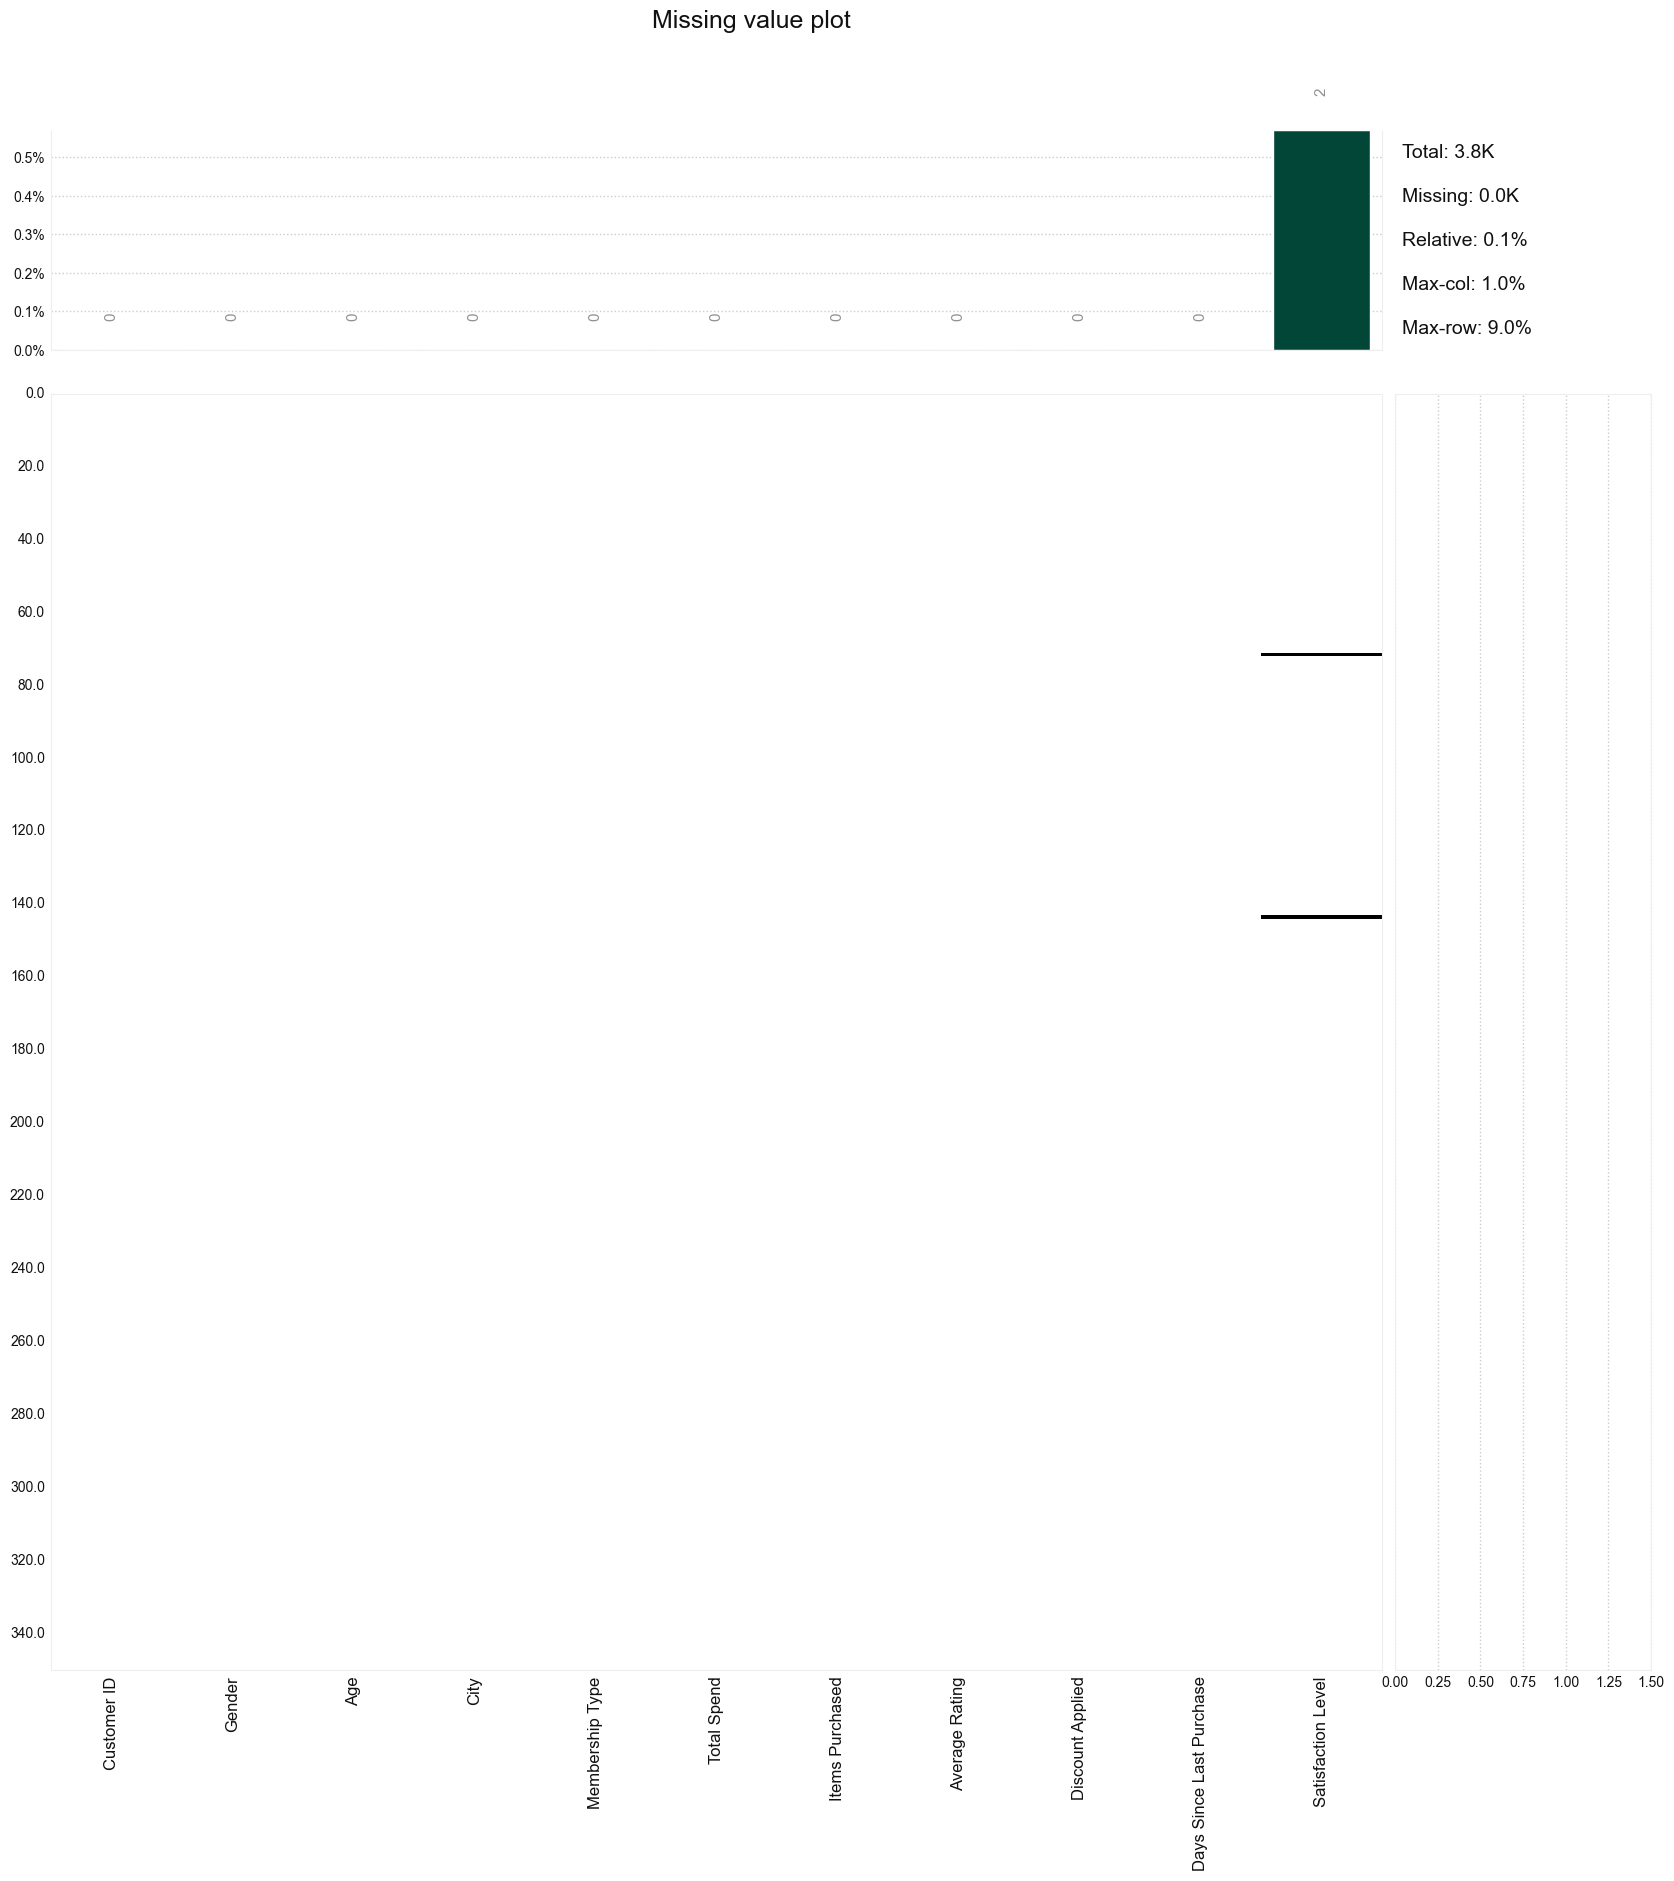

In [478]:
# Klib
import klib
klib.missingval_plot(df)

In [479]:
# df=klib.data_cleaning(df) -> preprocessingda muammo bo'layapti

In [480]:
# auto clean
# from datacleaner import autoclean
# df=autoclean(df)

In [481]:
# ma'lumot turlari
df.dtypes

Customer ID                   int64
Gender                          str
Age                           int64
City                            str
Membership Type                 str
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level              str
dtype: object

In [482]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [483]:
# matplotlib — asosiy grafik kutubxona
import matplotlib.pyplot as plt

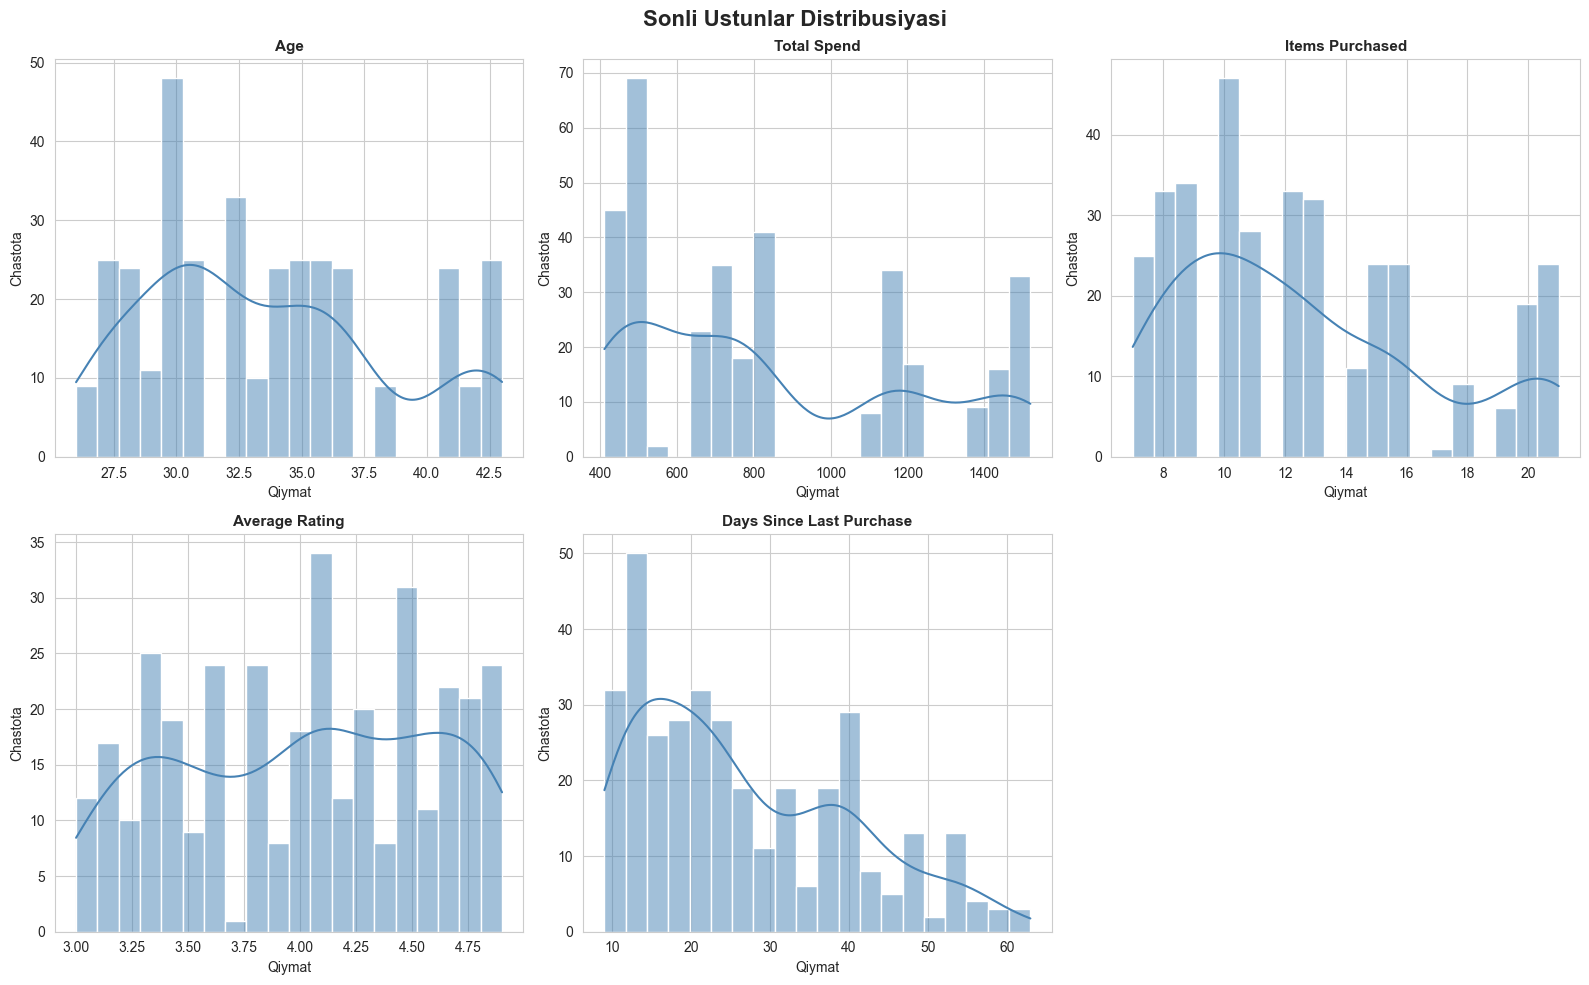

In [484]:
# seaborn — statistik vizualizatsiya (matplotlib ustida ishlaydi, chiroyliroq)
import seaborn as sns
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Sonli Ustunlar Distribusiyasi", fontsize=16, fontweight='bold')

# sonli ustunlarni tanlash
num_cols = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
# num_cols = df.select_dtypes(include=['int64','float64']).columns

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', bins=20)
    ax.set_title(f"{col}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Qiymat")
    ax.set_ylabel("Chastota")

axes[1][2].set_visible(False) # bo'sh subplotni yashirish
plt.tight_layout()
plt.show()

In [485]:
plt.savefig("Data_analysis/01_distribusiya.png",dpi=150, bbox_inches="tight")
print(" Grafik Data_analysis/ ga saqlandi.")

 Grafik Data_analysis/ ga saqlandi.


<Figure size 640x480 with 0 Axes>

C:\Users\WIN\AppData\Local\Temp\ipykernel_1888\181286649.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\WIN\AppData\Local\Temp\ipykernel_1888\181286649.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\WIN\AppData\Local\Temp\ipykernel_1888\181286649.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')


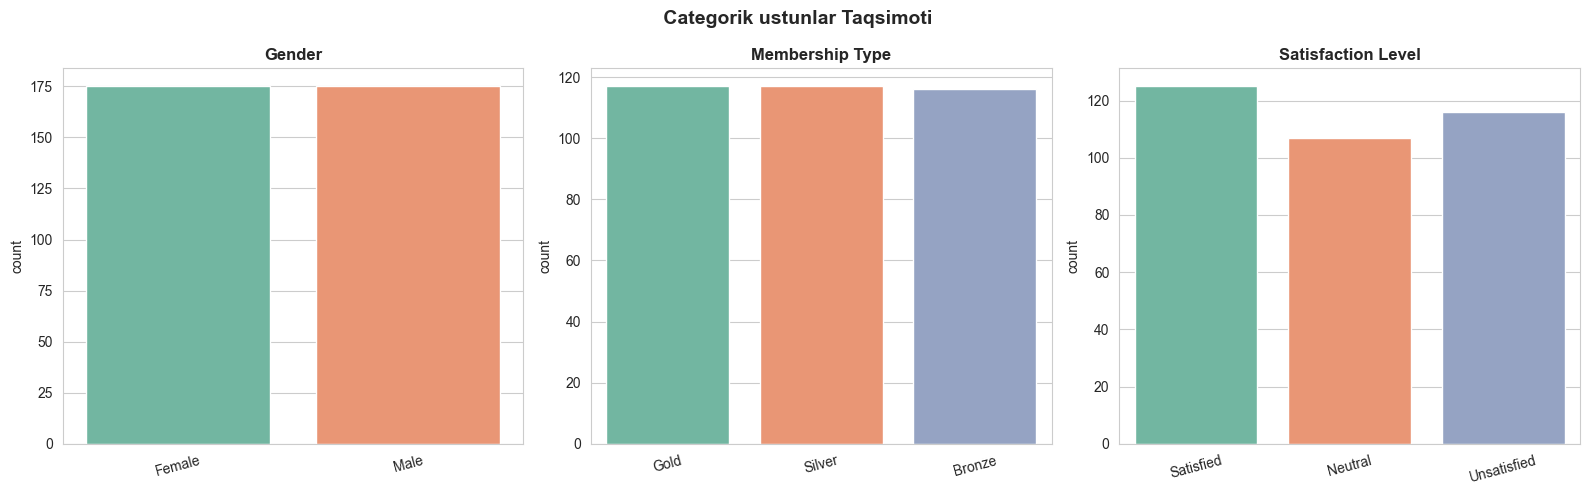

In [486]:
# Categorik ustunlar uchun countplot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(" Categorik ustunlar Taqsimoti", fontsize=14, fontweight='bold')

cat_cols = ['Gender', 'Membership Type', 'Satisfaction Level']
colors = ['steelblue','coral','mediumseagreen']

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x',rotation=15)

plt.tight_layout()
plt.savefig("Data_analysis/02_kategorik_taqsimot.png",dpi=150, bbox_inches='tight')
plt.show()

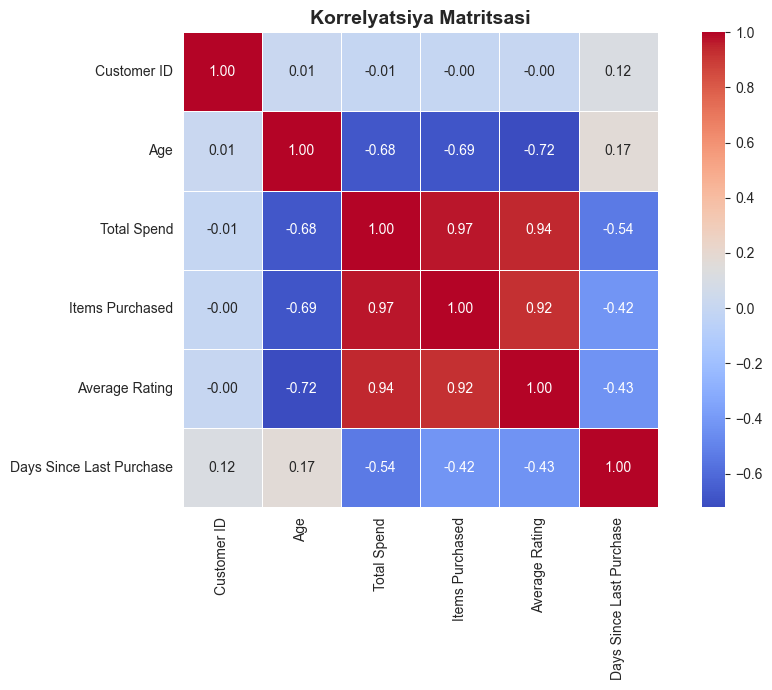

In [487]:
# Korrelyatsiya Heatmap
# Seaborn heatmapdan foydalanamiz
plt.figure(figsize=(10,7))
num_df = df.select_dtypes(include='number')
sns.heatmap(num_df.corr(),annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title("Korrelyatsiya Matritsasi", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Data_analysis/03_korrelyatsiya.png",dpi=150, bbox_inches='tight')
plt.show()

In [488]:
# plotly express — interaktiv vizualizatsiya uchun
import plotly.express as px

In [489]:
# Total Spend vs Items Purchased munosabatini interaktiv ko'rsatamiz
fig = px.scatter(
    df.dropna(),
    x='Items Purchased',
    y='Total Spend',
    color='Satisfaction Level',
    size='Age',
    hover_data=['Gender', 'City', 'Membership Type'],
    title="Items Purchased vs Total Spend (Interaktiv)",
    template='plotly_white'
)
fig.show()

In [490]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


---
## Data Preprocessing jarayoni

In [491]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from pandas.api.types import is_numeric_dtype


In [492]:
class DataPreprocessing:
    """
    Ma'lumotlarni tozalash va kodlash uchun to'liq pipeline
    """

    def __init__(self, df):
        self.df=df.copy()

    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if is_numeric_dtype(self.df[col]):
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
        return self

    def encodla(self):
        encoder=LabelEncoder()
        for col in self.df.columns:
            if (self.df[col].dtype=='str' or self.df[col].dtype=='bool'):
                if self.df[col].nunique()<=5:
                    dummies=pd.get_dummies(self.df[col],prefix=col,dtype=int)
                    self.df=pd.concat([self.df.drop(columns=[col]),dummies],axis=1)
                else:
                    self.df[col]=encoder.fit_transform(self.df[col])
        return self
    
    def scale_qil(self):
        scaler=MinMaxScaler()
        for col in self.df.columns:
            num_col = self.df.select_dtypes(include=['int64','float64']).columns.drop('Total Spend')
            self.df[num_col]=scaler.fit_transform(self.df[num_col])
        return self

In [493]:
dp = DataPreprocessing(df)
dp.tozala().encodla().scale_qil()
df=dp.df
print(f"\nPreprocessing jarayoni tugatildi.")


Preprocessing jarayoni tugatildi.


In [494]:
dp.df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer ID                     350 non-null    float64
 1   Age                             350 non-null    float64
 2   City                            350 non-null    float64
 3   Total Spend                     350 non-null    float64
 4   Items Purchased                 350 non-null    float64
 5   Average Rating                  350 non-null    float64
 6   Days Since Last Purchase        350 non-null    float64
 7   Gender_Female                   350 non-null    float64
 8   Gender_Male                     350 non-null    float64
 9   Membership Type_Bronze          350 non-null    float64
 10  Membership Type_Gold            350 non-null    float64
 11  Membership Type_Silver          350 non-null    float64
 12  Discount Applied_False          350 non-null   

In [495]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer ID                     350 non-null    float64
 1   Age                             350 non-null    float64
 2   City                            350 non-null    float64
 3   Total Spend                     350 non-null    float64
 4   Items Purchased                 350 non-null    float64
 5   Average Rating                  350 non-null    float64
 6   Days Since Last Purchase        350 non-null    float64
 7   Gender_Female                   350 non-null    float64
 8   Gender_Male                     350 non-null    float64
 9   Membership Type_Bronze          350 non-null    float64
 10  Membership Type_Gold            350 non-null    float64
 11  Membership Type_Silver          350 non-null    float64
 12  Discount Applied_False          350 non-null   

In [496]:
# Preprocessed datasetni saqlash
df.to_csv("Data/Preprocessed/ecommerce_preprocessed.csv",index=False)
print("Preprocessed data saqlandi: Data/Preprocessed/ecommerce_preprocessed.csv")

Preprocessed data saqlandi: Data/Preprocessed/ecommerce_preprocessed.csv


---
## Feature Engineering (yangi featurelar)

In [497]:
df_eng=df.copy()

# 1-ustun -> spend_per_item (bu mijozning premium xaridorligini aniqlaydi)
df_eng['spend_per_item']=df_eng['Total Spend']/(df_eng['Items Purchased']+1)
print("spend_per_item — har mahsulotga sarflangan o'rtacha pul")

spend_per_item — har mahsulotga sarflangan o'rtacha pul


In [498]:
# 2-ustun -> is_high_spender (binary feature — xaridor ko'p sarflaydimi?)
median_spend = df_eng['Total Spend'].median()
df_eng['is_high_spender'] = (df_eng['Total Spend']>median_spend).astype(int)
print(f"is_high_spender — median ({median_spend:.1f}) dan ko'p sarflaydi → 1")

is_high_spender — median (775.2) dan ko'p sarflaydi → 1


In [499]:
# 3-ustun -> engagement_index (rating × items_purchased — faollik ko'rsatkichi)
df_eng['engagement_index'] = df_eng['Average Rating'] * df_eng['Items Purchased']
print("engagement_index — faollik indeksi (rating × items)")
print(f"\nFeature Engineering tugadi. Yangi hajm: {df_eng.shape}")

engagement_index — faollik indeksi (rating × items)

Feature Engineering tugadi. Yangi hajm: (350, 20)


### Log transformation

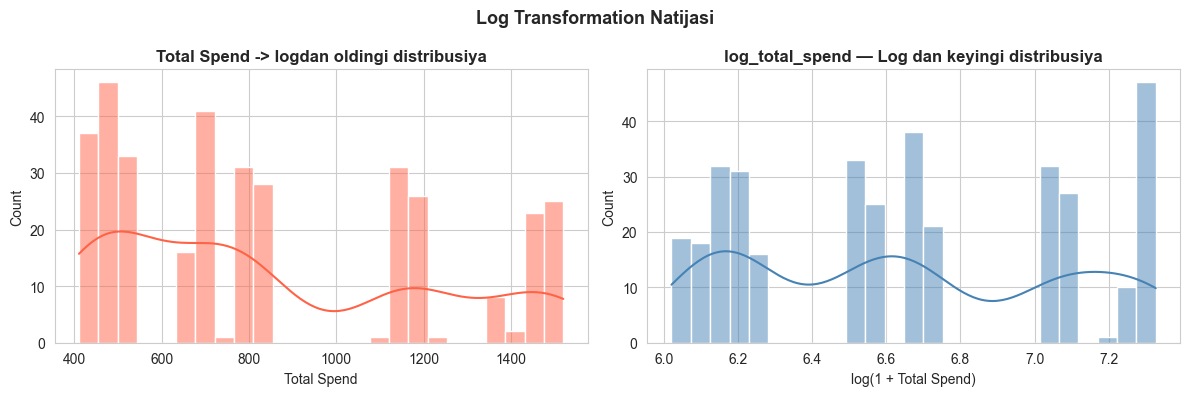

Log Transformation qo'llanildi: log_total_spend ustuni qo'shildi


In [500]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_eng['Total Spend'],kde=True, color='tomato', bins=25)
plt.title("Total Spend -> logdan oldingi distribusiya", fontweight='bold')
plt.xlabel("Total Spend")

# np.log1p — log(1+x) ya'ni 0 qiymat uchun xato bermasligi uchun
import numpy as np
df_eng['log_total_spend'] = np.log1p(df_eng['Total Spend'])

plt.subplot(1, 2, 2)
sns.histplot(df_eng['log_total_spend'], kde=True, color='steelblue', bins=25)
plt.title("log_total_spend — Log dan keyingi distribusiya", fontweight='bold')
plt.xlabel("log(1 + Total Spend)")

plt.suptitle("Log Transformation Natijasi", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Data_Analysis/04_log_transformation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Log Transformation qo'llanildi: log_total_spend ustuni qo'shildi")

In [501]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer ID                     350 non-null    float64
 1   Age                             350 non-null    float64
 2   City                            350 non-null    float64
 3   Total Spend                     350 non-null    float64
 4   Items Purchased                 350 non-null    float64
 5   Average Rating                  350 non-null    float64
 6   Days Since Last Purchase        350 non-null    float64
 7   Gender_Female                   350 non-null    float64
 8   Gender_Male                     350 non-null    float64
 9   Membership Type_Bronze          350 non-null    float64
 10  Membership Type_Gold            350 non-null    float64
 11  Membership Type_Silver          350 non-null    float64
 12  Discount Applied_False          350 non-null   

### Feature Selection

In [502]:
# RandomForestClassifier yordamida feature importance hisoblaymiz
from sklearn.ensemble import RandomForestClassifier

# Target: Satisfaction Level
encoder = LabelEncoder()
y_sel = encoder.fit_transform(df['Satisfaction Level_Neutral'].fillna('Neutral'))

feature_cols = [col for col in df_eng.columns if col not in [
    'Customer ID', 'Satisfaction Level_Neutral', 'Total Spend', 'log_total_spend', 'is_high_spender'
]]

X_sel = df_eng[feature_cols].fillna(0)

In [503]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer ID                     350 non-null    float64
 1   Age                             350 non-null    float64
 2   City                            350 non-null    float64
 3   Total Spend                     350 non-null    float64
 4   Items Purchased                 350 non-null    float64
 5   Average Rating                  350 non-null    float64
 6   Days Since Last Purchase        350 non-null    float64
 7   Gender_Female                   350 non-null    float64
 8   Gender_Male                     350 non-null    float64
 9   Membership Type_Bronze          350 non-null    float64
 10  Membership Type_Gold            350 non-null    float64
 11  Membership Type_Silver          350 non-null    float64
 12  Discount Applied_False          350 non-null   

In [504]:
# n_estimators=100 — 100 ta daraxtda sinab ko'ramiz
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_sel, y_sel)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [505]:
# Feature importance - har bir ustunni modelga ta'siri
importances = pd.Series(rf_sel.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

In [506]:
# Plotly Express — interaktiv feature importance grafigi
import plotly.express as px

fig = px.bar(
    x=importances.values,
    y=importances.index,
    title="Feature Importance (RandomForest asosida)",
    labels={'x': 'Importance darajasi', 'y': 'Feature nomi'},
    color=importances.values,
    color_continuous_scale='blues'
)
fig.update_layout(height=500)
fig.show()

# Eng muhim 8 ta featureni tanlaymiz
top_features=importances.nlargest(8).index.tolist()
print(f"\n Eng muhim 8 ta feature: {top_features}")


 Eng muhim 8 ta feature: ['Discount Applied_False', 'Items Purchased', 'Age', 'Discount Applied_True', 'engagement_index', 'City', 'Satisfaction Level_Satisfied', 'Satisfaction Level_Unsatisfied']


In [507]:
fig.write_image("Data_analysis/05_feature_importance.png")

## Scaling: feature selectiondan keyin qilamiz

In [508]:
from sklearn.preprocessing import MinMaxScaler

scale_cols = [c for c in df_eng.select_dtypes(include='number').columns
              if c not in ['Customer ID', 'is_high_spender']]
scaler = MinMaxScaler()
df_eng[scale_cols] = scaler.fit_transform(df_eng[scale_cols])

print("⚖️ MinMaxScaler qo'llanildi")
print(f"   Scale qilingan ustunlar: {scale_cols}")

⚖️ MinMaxScaler qo'llanildi
   Scale qilingan ustunlar: ['Age', 'City', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase', 'Gender_Female', 'Gender_Male', 'Membership Type_Bronze', 'Membership Type_Gold', 'Membership Type_Silver', 'Discount Applied_False', 'Discount Applied_True', 'Satisfaction Level_Neutral', 'Satisfaction Level_Satisfied', 'Satisfaction Level_Unsatisfied', 'spend_per_item', 'engagement_index', 'log_total_spend']


In [509]:
# Engineered datasetni saqlaymiz
df_eng.to_csv("Data/Engineered/ecommerce_engineered.csv", index=False)
print("\nEngineered data saqlandi: Data/Engineered/ecommerce_engineered.csv")


Engineered data saqlandi: Data/Engineered/ecommerce_engineered.csv


---
## Model Training & Selection

In [510]:
# Train/Test bo'lishish uchun
from sklearn.model_selection import train_test_split

In [511]:
# Umumiy feature ustunlar (ikkalasi uchun)
feature_cols = [col for col in df_eng.columns if col not in [
    'Customer ID', 'Satisfaction Level', 'Satisfaction_Encoded',
    'Total Spend', 'Log_Total_Spend', 'Is_High_Spender'
]]
X = df_eng[feature_cols].fillna(0)

In [512]:
    # Classification
# Classification uchun target
le_sat = LabelEncoder()
df_eng['Satisfaction_Encoded'] = le_sat.fit_transform(
    df['Satisfaction Level_Neutral'].fillna('Neutral')
)
y_clf = df_eng['Satisfaction_Encoded']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [513]:
    # Regression
y_reg = df_eng['log_total_spend']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [514]:

print(f"\nTrain (classification): {X_train_c.shape}, Test: {X_test_c.shape}")
print(f"Train (regression):     {X_train_r.shape}, Test: {X_test_r.shape}")


Train (classification): (280, 19), Test: (70, 19)
Train (regression):     (280, 19), Test: (70, 19)


---
## Barcha model kutubxonalarini chaqirib olamiz

In [515]:
    # Linear Models
from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression, 
    Lasso,              # L1 regularizatsiya — keraksiz featurelarni 0 qiladi
    Ridge               # L2 regularizatsiya — katta koeffitsientlarni kamaytiradi
)

In [516]:
    # Tree-based Models
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor
)

In [517]:
    # Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    BaggingClassifier,
    BaggingRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

In [518]:
    # Support Vector Machine Models
from sklearn.svm import SVC, SVR

In [519]:
## Metrikalar (Metrics)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)

In [520]:
# Joblib
import joblib

---
## Classification Modellar

In [521]:
clf_results = []

def train_clf(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    result = {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1_score':  round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }
    clf_results.append(result)

    # Modellarni JOBLIB va Modelsga saqlash
    safe_name = name.replace(" ", "_").replace("(","").replace(")","")
    joblib.dump(model, f"Joblib_files/clf_{safe_name}.joblib")
    joblib.dump(model, f"Models/clf_{safe_name}.pkl")

    print(f"{name:35s} | Acc: {result['Accuracy']:.4f} | F1: {result['F1_score']:.4f}")
    return model, y_pred

print("Classification Modellar Trening: ")

Classification Modellar Trening: 


In [522]:
# 1.Logistic Regression
m_lr_c, p_lr_c = train_clf("Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)
# m_lr_c → trained model.fit (LogisticRegression)
# p_lr_c → predictions (y_pred)

Logistic Regression                 | Acc: 1.0000 | F1: 1.0000


In [523]:
# 2.Decision Tree Classifier
m_dt_c, p_dt_c = train_clf("Decision Tree Classifier",
    DecisionTreeClassifier(max_depth=5, random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)

Decision Tree Classifier            | Acc: 1.0000 | F1: 1.0000


In [524]:
# 3. Random Forest Classifier
m_rf_c, p_rf_c = train_clf("Random Forest Classifier",
    RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)

Random Forest Classifier            | Acc: 1.0000 | F1: 1.0000


In [525]:
# 4. SVC (Support Vector Classifier)
m_svc, p_svc = train_clf("SVC (RBF kernel)",
    SVC(kernel='rbf',C=1.0, random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)

SVC (RBF kernel)                    | Acc: 1.0000 | F1: 1.0000


In [526]:
# 5. Lasso CLassification (LogisticRegression + L1)
m_lasso_c, p_lasso_c = train_clf("Lasso (L1) Classifier",
    LogisticRegression(penalty='l1', solver='saga', max_iter=2000, random_state=42),
    # LogisticRegression(C=1.0, solver='saga', max_iter=2000, random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)
# penalty='l1' — L1 regularizatsiya, ba'zi koeffitsientlarni 0 qiladi (feature selection)
# solver='saga' — L1 uchun mos solver


Lasso (L1) Classifier               | Acc: 1.0000 | F1: 1.0000


C:\Users\WIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\WIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [527]:
# 6. Ridge Classification (LogisticRegression + L2)
m_ridge_c, p_ridge_c = train_clf("Ridge (L2) Classifier",
    LogisticRegression(penalty='l2', max_iter=1000,random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)

Ridge (L2) Classifier               | Acc: 1.0000 | F1: 1.0000


C:\Users\WIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


---
## Ensemble Methods: Classification

In [528]:
# 7. Bagging Classifier
m_bag_c, p_bag_c = train_clf("Bagging Classifier",
    BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=50, max_samples=0.8, random_state=42
    ),
    X_train_c, X_test_c, y_train_c, y_test_c)

Bagging Classifier                  | Acc: 1.0000 | F1: 1.0000


In [529]:
# 8. Gradient Boosting Classifier
m_boost_c, p_boost_c = train_clf("Gradient Boosting Classifier",
    GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
        # Boosting — har bir model oldingi modelning XATOLARINI tuzatadi
        # learning_rate=0.1 — har qadamning o'rganish tezligi
    ),
    X_train_c, X_test_c, y_train_c, y_test_c)


Gradient Boosting Classifier        | Acc: 1.0000 | F1: 1.0000


In [530]:
%pip install xgboost
# 9. XGBoost Classifier (kuchli boosting)
from xgboost import XGBClassifier
m_xgb_c, p_xgb_c = train_clf("XGBoost Classifier",
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
XGBoost Classifier                  | Acc: 1.0000 | F1: 1.0000



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\WIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Regression Modellari

In [531]:
reg_results = []

def train_reg(name, model, X_tr, X_te, y_tr, y_te):
    """Regression modelni trening qilib, metrikalarni qaytaradi"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse= np.sqrt(mse)
    r2 = r2_score(y_te, y_pred)

    result = {
        'Model' : name,
        'MAE' : round(mae, 4),
        'MSE':  round(mse, 4),
        'RMSE': round(rmse, 4),
        'R^2' : round(r2, 4)
    }
    reg_results.append(result)

    safe_name = name.replace(" ", "_").replace("(","").replace(")", "")
    joblib.dump(model, f"Joblib_files/reg_{safe_name}.joblib")
    joblib.dump(model, f"Models/reg_{safe_name}.pkl")

    print(f" {name:35s} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")
    return model, y_pred

print("Regression Modellari Trening:")

Regression Modellari Trening:


In [532]:
    # 1. Linear Regression
m_lr_r, p_lr_r = train_reg("Linear Regression",
    LinearRegression(),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Linear Regression                   | MAE: 0.0000 | MSE: 0.0000 | RMSE: 0.0000 | R^2: 1.0000


In [533]:
    # 2. Decision Tree Regressor
m_dt_r, p_dt_r = train_reg("Decision Tree Regressor",
    DecisionTreeRegressor(max_depth=5, random_state=42),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Decision Tree Regressor             | MAE: 0.0040 | MSE: 0.0001 | RMSE: 0.0118 | R^2: 0.9987


In [534]:
    # 3. Random Forest Regressor
m_rf_r, p_rf_r = train_reg("Random FOrest Regressor",
    RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Random FOrest Regressor             | MAE: 0.0012 | MSE: 0.0000 | RMSE: 0.0048 | R^2: 0.9998


In [535]:
    # 4. SVR (Support Vector Regression)
m_svr, p_svr = train_reg("SVR (RBF kernel)",
    SVR(kernel='rbf', C=1.0),
    X_train_r, X_test_r, y_train_r, y_test_r)

 SVR (RBF kernel)                    | MAE: 0.0576 | MSE: 0.0040 | RMSE: 0.0633 | R^2: 0.9619


In [536]:
    # 5. Lasso Regression (L1)
m_lasso_r, p_lasso_r = train_reg("Lasso (L1) Regressor",
    Lasso(alpha=0.01, max_iter=5000),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Lasso (L1) Regressor                | MAE: 0.0337 | MSE: 0.0020 | RMSE: 0.0452 | R^2: 0.9806


In [537]:
    # 6. Ridge Regression (L2)
m_ridge_r, p_ridge_r = train_reg("Ridge (L2) Regressor",
    Ridge(alpha=1.0),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Ridge (L2) Regressor                | MAE: 0.0092 | MSE: 0.0002 | RMSE: 0.0134 | R^2: 0.9983


---
## Ensemble Methods: Regression

In [538]:
    # 7. Bagging Regressor
m_bag_r, p_bag_r = train_reg("Bagging Regressor",
    BaggingRegressor(n_estimators=50, max_samples=0.8, random_state=42),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Bagging Regressor                   | MAE: 0.0017 | MSE: 0.0000 | RMSE: 0.0059 | R^2: 0.9997


In [539]:
    # 8. Gradient Boosting Regressor
m_boost_r, p_boost_r = train_reg("Gradient Boosting Regressor",
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    X_train_r, X_test_r, y_train_r, y_test_r)

 Gradient Boosting Regressor         | MAE: 0.0010 | MSE: 0.0000 | RMSE: 0.0060 | R^2: 0.9997


In [541]:
%pip install xgboost
    # 9. XGBoost Regressor
from xgboost import XGBRegressor
m_xgb_r, p_xgb_r = train_reg("XGBoost Regressor",
    XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    X_train_r, X_test_r, y_train_r, y_test_r)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
 XGBoost Regressor                   | MAE: 0.0004 | MSE: 0.0000 | RMSE: 0.0017 | R^2: 1.0000



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\WIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
# Model Evaluation (Modellarni baholash)

In [ ]:
# Classification
from sklearn.metrics import confusion_matrix, classification_report

top_clf_models = [
    ("Random Forest", p_rf_c),
    ("XGBoost", p_xgb_c),
    ("Gradient Boosting", p_boost_c)
]

print("Classification — Confusion Matrix (Eng yaxshi 3 model)\n")

for name, preds in top_clf_models:
    print(f"{name}")
    cm = confusion_matrix(y_test_c, preds)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test_c, preds))


Classification — Confusion Matrix (Eng yaxshi 3 model)

Random Forest

Confusion Matrix:
[[47  0]
 [ 0 23]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

XGBoost

Confusion Matrix:
[[47  0]
 [ 0 23]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

Gradient Boosting

Confusion Matrix:
[[47  0]
 [ 0 23]]

Classification Report:
              precision    recall  f1-score   support

         

In [549]:
# Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

top_reg_models = [
    ("Random Forest", p_rf_r),
    ("XGBoost", p_xgb_r),
    ("Gradient Boosting", p_boost_r)
]

print("Regression — Model Evaluation\n")

for name, preds in top_reg_models:
    mae = mean_absolute_error(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    r2 = r2_score(y_test_r, preds)

    print(f"\t{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

Regression — Model Evaluation

	Random Forest
MAE  : 0.0012
RMSE : 0.0048
R²   : 0.9998
	XGBoost
MAE  : 0.0004
RMSE : 0.0017
R²   : 1.0000
	Gradient Boosting
MAE  : 0.0010
RMSE : 0.0060
R²   : 0.9997


---
## Cross Validation (K-Fold)

In [550]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

In [557]:
# Classification Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Classification -> 5-Fold Cross Validation:")
print()

clf_cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=50, random_state=42),
    "XGBoost Classifier": XGBClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting Clf": GradientBoostingClassifier(n_estimators=50, random_state=42),
}

clf_cv_results = []
for name, model in clf_cv_models.items():
    scores = cross_val_score(model, X, y_clf, cv=skf)
    clf_cv_results.append({
        'Model': name,
        'CV Mean F1': round(scores.mean(), 4),
        'CV Std':     round(scores.std(), 4),
        'Min':        round(scores.min(), 4),
        'Max':        round(scores.max(), 4)
    })
    print(f" {name:.35s} | F1: {scores.mean():.4f} ± {scores.std():.4f}")

    clf_cv_df = pd.DataFrame(clf_cv_results)

Classification -> 5-Fold Cross Validation:

 Logistic Regression | F1: 1.0000 ± 0.0000
 Random Forest Classifier | F1: 1.0000 ± 0.0000
 XGBoost Classifier | F1: 1.0000 ± 0.0000
 Gradient Boosting Clf | F1: 1.0000 ± 0.0000


In [558]:
# Regression Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Regression -> 5-Fold Cross Validation:")
print()

reg_cv_models = {
    "Linear Regression":       LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=50, random_state=42),
    "XGBoost Regressor":       XGBRegressor(n_estimators=50, random_state=42),
    "Gradient Boosting Reg":   GradientBoostingRegressor(n_estimators=50, random_state=42),
}

reg_cv_results = []
for name, model in reg_cv_models.items():
    scores = cross_val_score(model, X, y_reg, cv=kf)
    rmse_scores = -scores
    reg_cv_results.append({
        'Model': name,
        'CV Mean RMSE': round(rmse_scores.mean(), 4),
        'CV Std': round(rmse_scores.std(), 4),
    })
    print(f" {name:.35s} | RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

reg_cv_df = pd.DataFrame(reg_cv_results)

Regression -> 5-Fold Cross Validation:

 Linear Regression | RMSE: -1.0000 ± 0.0000
 Random Forest Regressor | RMSE: -0.9997 ± 0.0003
 XGBoost Regressor | RMSE: -0.9969 ± 0.0056
 Gradient Boosting Reg | RMSE: -0.9998 ± 0.0001


---
## Tabulate bilan Modellarni Taqqoslash

In [559]:
from  tabulate import tabulate

In [571]:
print(pd.DataFrame(clf_results).head())

                      Model  Accuracy  Precision  Recall  F1_score
0       Logistic Regression       1.0        1.0     1.0       1.0
1  Decision Tree Classifier       1.0        1.0     1.0       1.0
2  Random Forest Classifier       1.0        1.0     1.0       1.0
3          SVC (RBF kernel)       1.0        1.0     1.0       1.0
4     Lasso (L1) Classifier       1.0        1.0     1.0       1.0


In [580]:
# Classification + Tabulate
print("Classification Modellar")

clf_df = pd.DataFrame(clf_results).sort_values('F1_score', ascending=False).reset_index(drop=True)
clf_df.index += 1
print(tabulate(clf_df, headers='keys', tablefmt='fancy_grid', showindex=True))

best_clf = clf_df.iloc[0]
print(f"\n Eng yaxshi Classification modeli: {best_clf['Model']}")
print(f" F1_score: {best_clf['F1_score']:.4f} | Accuracy: {best_clf['Accuracy']:.4f}")

Classification Modellar
╒════╤══════════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│    │ Model                        │   Accuracy │   Precision │   Recall │   F1_score │
╞════╪══════════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│  1 │ Logistic Regression          │          1 │           1 │        1 │          1 │
├────┼──────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│  2 │ Decision Tree Classifier     │          1 │           1 │        1 │          1 │
├────┼──────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│  3 │ Random Forest Classifier     │          1 │           1 │        1 │          1 │
├────┼──────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│  4 │ SVC (RBF kernel)             │          1 │           1 │        1 │          1 │
├────┼──────────────────────────────┼────────────┼─────────────┼──────────┼───────────

In [579]:
# Regression + Tabulate
print("Regression Modellar")

reg_df = pd.DataFrame(reg_results).sort_values('R^2', ascending=False).reset_index(drop=True)
reg_df.index += 1
print(tabulate(reg_df, headers='keys', tablefmt='fancy_grid',showindex=True))

best_reg = reg_df.iloc[0]
print(f"Eng yaxshi Regression modeli: {best_reg['Model']}")
print(f"R^2: {best_reg['R^2']:.4f} | RMSE: {best_reg['RMSE']:.4f}")

Regression Modellar
╒════╤═════════════════════════════╤════════╤════════╤════════╤════════╕
│    │ Model                       │    MAE │    MSE │   RMSE │    R^2 │
╞════╪═════════════════════════════╪════════╪════════╪════════╪════════╡
│  1 │ Linear Regression           │ 0      │ 0      │ 0      │ 1      │
├────┼─────────────────────────────┼────────┼────────┼────────┼────────┤
│  2 │ XGBoost Regressor           │ 0.0004 │ 0      │ 0.0017 │ 1      │
├────┼─────────────────────────────┼────────┼────────┼────────┼────────┤
│  3 │ Random FOrest Regressor     │ 0.0012 │ 0      │ 0.0048 │ 0.9998 │
├────┼─────────────────────────────┼────────┼────────┼────────┼────────┤
│  4 │ Bagging Regressor           │ 0.0017 │ 0      │ 0.0059 │ 0.9997 │
├────┼─────────────────────────────┼────────┼────────┼────────┼────────┤
│  5 │ Gradient Boosting Regressor │ 0.001  │ 0      │ 0.006  │ 0.9997 │
├────┼─────────────────────────────┼────────┼────────┼────────┼────────┤
│  6 │ Decision Tree Regressor 

---
# Natijalar va Modellarni saqlash jarayoni

In [587]:
# Eng yaxshi Classification model
best_clf_name = best_clf['Model'].replace(" ", "_")
joblib.dump(m_rf_c if 'Random Forest' in best_clf['Model'] else m_boost_c,
            f"Joblib_files/Best_clf_{best_clf_name}.joblib")
joblib.dump(le_sat, "Joblib_files/label_encoder_satisfaction.joblib")
joblib.dump(scaler, "Joblib_files/minmax_scaler.joblib")
joblib.dump(encoder, "Joblib_files/encoder.joblib")

print("Eng yaxshi modellar Joblib_files/ ga saqlandi:")
for f in os.listdir("Joblib_files"):
    print(f"   {f}")

Eng yaxshi modellar Joblib_files/ ga saqlandi:
   Best_clf_Logistic_Regression.joblib
   clf_Bagging_Classifier.joblib
   clf_Decision_Tree_Classifier.joblib
   clf_Gradient_Boosting_Classifier.joblib
   clf_Lasso_L1_Classifier.joblib
   clf_Logistic_Regression.joblib
   clf_Random_Forest_Classifier.joblib
   clf_Ridge_L2_Classifier.joblib
   clf_SVC_RBF_kernel.joblib
   clf_XGBoost_Classifier.joblib
   encoder.joblib
   label_encoder_satisfaction.joblib
   minmax_scaler.joblib
   reg_Bagging_Regressor.joblib
   reg_Decision_Tree_Regressor.joblib
   reg_Gradient_Boosting_Regressor.joblib
   reg_Lasso_L1_Regressor.joblib
   reg_Linear_Regression.joblib
   reg_Random_FOrest_Regressor.joblib
   reg_Ridge_L2_Regressor.joblib
   reg_SVR_RBF_kernel.joblib
   reg_XGBoost_Regressor.joblib


In [589]:
# Prediction (Bashoratlarni saqlaymiz)
pred_df = pd.DataFrame({
    'Actual_Satisfaction': le_sat.inverse_transform(y_test_c),
    'Predicted_Satisfaction': le_sat.inverse_transform(p_rf_c),
    'Actual_Log_Spend': y_test_r.values,
    'Predicted_Log_Spend': p_xgb_r,
})
pred_df.to_csv("Data/Predictions/model_predictions.csv", index=False)
print(" Bashoratlar saqlandi: Data/Predictions/model_predictions.csv")

# Taqqoslash jadvallarini Tabulateni saqlash
clf_df.to_csv("Data_Analysis/classification_results.csv", index=False)
reg_df.to_csv("Data_Analysis/regression_results.csv", index=False)
clf_cv_df.to_csv("Data_Analysis/classification_cv_results.csv", index=False)
reg_cv_df.to_csv("Data_Analysis/regression_cv_results.csv", index=False)
print("Tabulate natijalari Data_Analysis/ ga saqlandi")

 Bashoratlar saqlandi: Data/Predictions/model_predictions.csv
Tabulate natijalari Data_Analysis/ ga saqlandi
